# **Chatbot sobre documentos con Qwen y Gradio: integración de modelos open source en Colab**

**Objetivo y alcance del trabajo**

El objetivo de este componente práctico es implementar un chatbot capaz de responder preguntas sobre el contenido de documentos en formato PDF, utilizando modelos de lenguaje open source alojados en Hugging Face específicamente Qwen1.5-0.5B-Chat y una interfaz conversacional construida con Gradio, simulando el estilo de ChatGPT.
El sistema está diseñado para ejecutarse en Google Colab, donde los documentos se cargan previamente en la carpeta /content. A partir de estos archivos, se extrae el contenido textual, se fragmenta, se transforma en vectores semánticos mediante sentence-transformers, se indexa con FAISS, y se utiliza un modelo generativo para responder preguntas en lenguaje natural.
La interfaz permite mantener una conversación contextualizada con el contenido de los documentos, simulando una experiencia de lectura asistida por inteligencia artificial.
Este ejercicio busca que el estudiante se familiarice con:

* 	El procesamiento de documentos en Python.
* 	La generación de embeddings semánticos.
*	  La búsqueda eficiente con FAISS.
*	  La integración de modelos de lenguaje generativos.
*	  El desarrollo de interfaces conversacionales accesibles desde el navegador.
*	  La visualización de estadísticas básicas del documento.

En clase se trabajará exclusivamente con archivos PDF. Como parte de la tarea, cada estudiante deberá extender el sistema para incluir otros formatos como DOCX, TXT y XLSX.


In [1]:

# Instalación de librerías

!pip install -q transformers sentence-transformers faiss-cpu gradio pymupdf python-docx openpyxl wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 12.4 MB/s eta 0:00:00


In [2]:

# Importar librerías necesarias

import os
import fitz
import torch
import faiss
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re
from sentence_transformers import SentenceTransformer
import gradio as gr
from transformers import AutoTokenizer, AutoModelForCausalLM
from docx import Document

### **Fase I – Procesamiento y análisis del documento**
En esta fase se procesa un archivo PDF ubicado en la carpeta /content de Colab. Se utiliza la librería PyMuPDF para extraer el texto del documento.
El contenido se divide en fragmentos de 500 caracteres para facilitar su indexación y recuperación. Además, se realiza un análisis básico del texto, incluyendo:


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

# Fase I - Procesamiento y análisis del documento

def leer_pdf(ruta):
    """Función para leer archivos PDF"""
    documento = fitz.open(ruta)
    texto_paginas = []
    for pagina in documento:
        texto_paginas.append(pagina.get_text())
    return "\n".join(texto_paginas)

def leer_docx(ruta):
    """Función para leer archivos DOCX"""
    doc = Document(ruta)
    texto_completo = []
    for parrafo in doc.paragraphs:
        texto_completo.append(parrafo.text)
    return "\n".join(texto_completo)

def leer_txt(ruta):
    """Función para leer archivos TXT"""
    with open(ruta, 'r', encoding='utf-8') as archivo:
        return archivo.read()

def leer_xlsx(ruta):
    """Función para leer archivos XLSX"""
    df = pd.read_excel(ruta)
    texto_completo = []
    for columna in df.columns:
        texto_completo.extend(df[columna].dropna().astype(str).tolist())
    return "\n".join(texto_completo)

def cargar_documentos(ruta_carpeta):
    """Carga todos los documentos de la carpeta en diferentes formatos"""
    documentos = []
    for nombre_archivo in os.listdir(ruta_carpeta):
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

        if nombre_archivo.endswith(".pdf"):
            documentos.append(leer_pdf(ruta_completa))
        elif nombre_archivo.endswith(".docx"):
            documentos.append(leer_docx(ruta_completa))
        elif nombre_archivo.endswith(".txt"):
            documentos.append(leer_txt(ruta_completa))
        elif nombre_archivo.endswith(".xlsx"):
            documentos.append(leer_xlsx(ruta_completa))

    return documentos

def analizar_texto(texto):
    """Realiza análisis básico del texto"""
    # Limpiar y tokenizar
    palabras = re.findall(r'\b\w+\b', texto.lower())

    # Estadísticas básicas
    total_palabras = len(palabras)
    palabras_unicas = len(set(palabras))

    # Palabras más frecuentes
    contador_palabras = Counter(palabras)
    palabras_frecuentes = contador_palabras.most_common(20)

    return {
        'total_palabras': total_palabras,
        'palabras_unicas': palabras_unicas,
        'palabras_frecuentes': palabras_frecuentes,
        'todas_palabras': palabras
    }

def crear_grafico_palabras_frecuentes(palabras_frecuentes):
    """Crea gráfico de barras con las palabras más frecuentes"""
    palabras, frecuencias = zip(*palabras_frecuentes)

    plt.figure(figsize=(12, 8))
    plt.bar(palabras, frecuencias)
    plt.title('20 Palabras Más Frecuentes')
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt

def crear_nube_palabras(todas_palabras):
    """Crea nube de palabras"""
    texto_para_nube = ' '.join(todas_palabras)

    nube_palabras = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100
    ).generate(texto_para_nube)

    plt.figure(figsize=(12, 6))
    plt.imshow(nube_palabras, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nube de Palabras')
    return plt


*   Conteo total de palabras.

*   Identificación de las palabras más frecuentes.

*   Visualización de estos datos mediante gráficos (por ejemplo, barras o nubes de palabras).


Estadísticas del documento:
Total de palabras: 4469
Palabras únicas: 1342

Top 10 palabras más frecuentes:
  de: 219
  la: 169
  y: 118
  en: 107
  el: 91
  los: 90
  o: 71
  un: 65
  a: 61
  del: 57


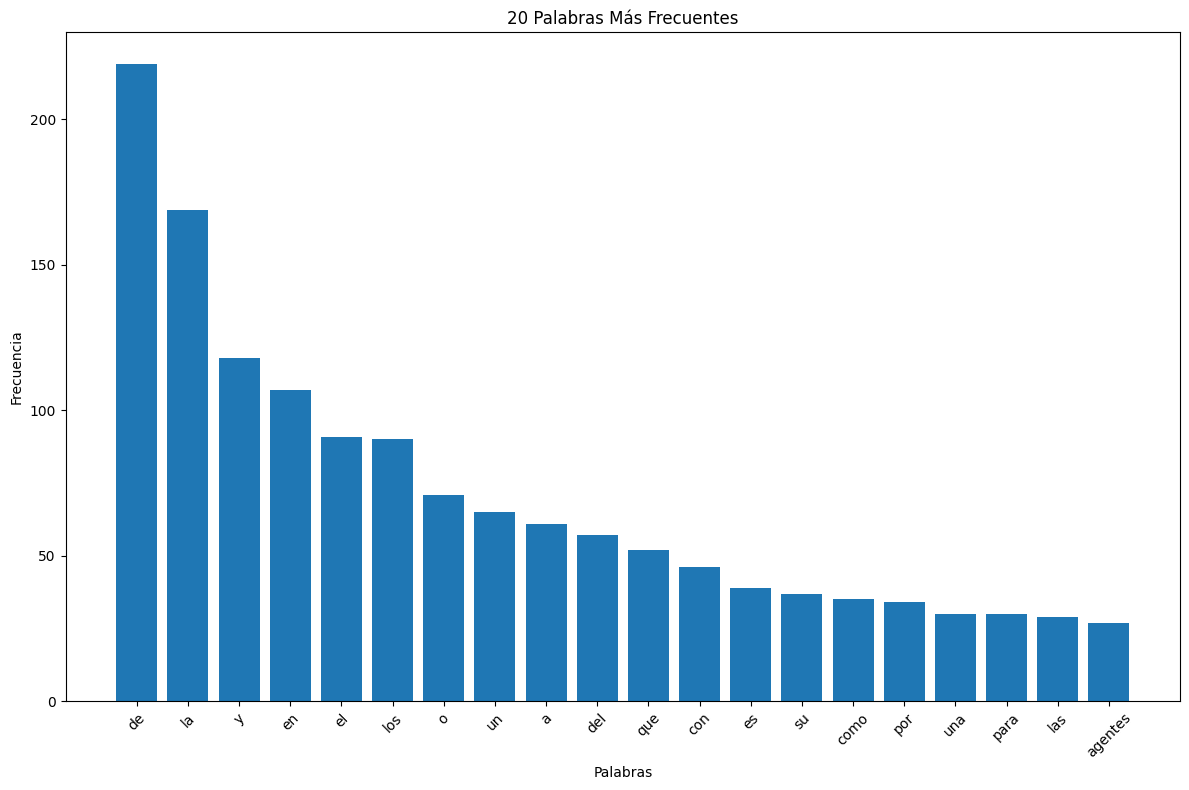

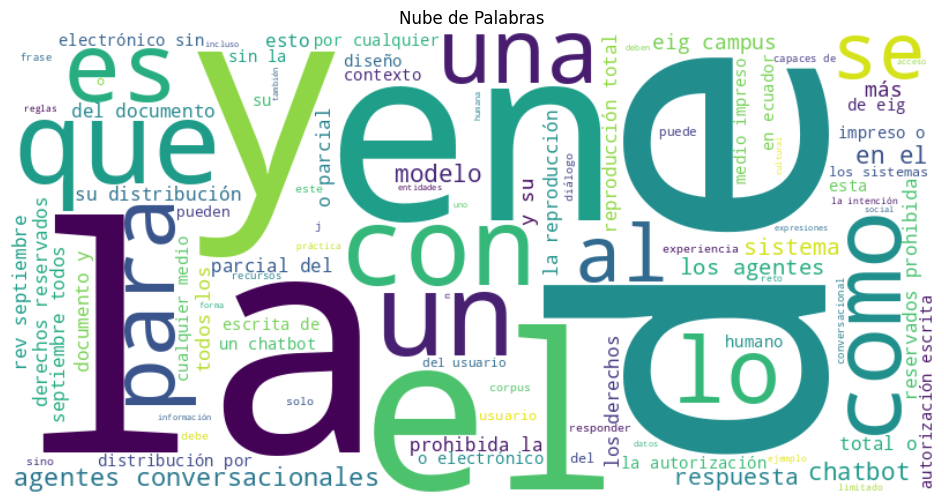

In [11]:

# Procesar documentos

ruta_carpeta = "/content"
documentos = cargar_documentos(ruta_carpeta)

if documentos:
    # Combinar todos los documentos para análisis
    texto_completo = "\n".join(documentos)

    # Realizar análisis
    analisis = analizar_texto(texto_completo)

    print(f"Estadísticas del documento:")
    print(f"Total de palabras: {analisis['total_palabras']}")
    print(f"Palabras únicas: {analisis['palabras_unicas']}")
    print(f"\nTop 10 palabras más frecuentes:")
    for palabra, frecuencia in analisis['palabras_frecuentes'][:10]:
        print(f"  {palabra}: {frecuencia}")

    # Mostrar gráficos
    grafico_barras = crear_grafico_palabras_frecuentes(analisis['palabras_frecuentes'])
    grafico_barras.show()

    nube = crear_nube_palabras(analisis['todas_palabras'])
    nube.show()
else:
    print("No se encontraron documentos en la carpeta /content")
    texto_completo = ""


## **Fase II – Indexación semántica con FAISS**
Cada fragmento se convierte en un vector semántico utilizando el modelo all-MiniLM-L6-v2 de sentence-transformers. Estos vectores se almacenan en un índice FAISS, que permite realizar búsquedas rápidas y precisas de los fragmentos más relevantes en función de una pregunta del usuario.

Este enfoque permite que el chatbot responda con base en el contenido real del documento, sin necesidad de entrenar un modelo desde cero.


In [12]:

# Fragmentar documentos para el chatbot

# ACTUALIZACION: fragmentación por caracteres (más control del tamaño del contexto)
def fragmentar_por_caracteres(texto, max_chars=1200, overlap=250):
    frags = []
    i = 0
    n = len(texto)
    while i < n:
        j = min(n, i + max_chars)
        frags.append(texto[i:j])
        if j == n: break
        i = j - overlap if j - overlap > i else j
    return frags

# Construir 'fragmentos' a partir de 'documentos'
fragmentos = []
for doc in documentos:
    fragmentos.extend(fragmentar_por_caracteres(doc, max_chars=1200, overlap=250))

print(f"Fragmentos creados: {len(fragmentos)} (≈1200 chars c/u, overlap=250)")

Fragmentos creados: 34 (≈1200 chars c/u, overlap=250)


In [13]:

# Fase II - Indexación semántica con FAISS

MODELO_EMBEDDINGS = "all-MiniLM-L6-v2"

if fragmentos:
    codificador = SentenceTransformer(MODELO_EMBEDDINGS)
    embeddings = codificador.encode(fragmentos, convert_to_numpy=True)
    indice = faiss.IndexFlatL2(embeddings.shape[1])
    indice.add(embeddings)
    print(f"Índice FAISS creado con {len(fragmentos)} fragmentos")
else:
    codificador = None
    indice = None
    print("No hay fragmentos para indexar")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Índice FAISS creado con 34 fragmentos


## **Fase III – Generación de respuestas e interfaz conversacional**
Se utiliza el modelo Qwen1.5-0.5B-Chat, alojado en Hugging Face, para generar respuestas en lenguaje natural. El modelo recibe como entrada un prompt estructurado tipo chat, que incluye el contexto recuperado por FAISS y la pregunta del usuario.

La interfaz se construye con gr.Blocks y gr.Chatbot, simulando una experiencia tipo ChatGPT. El usuario puede ingresar preguntas, visualizar el historial de conversación y exportarlo como archivo .txt.

Todo el sistema se ejecuta en Colab, sin necesidad de servidores externos.


In [14]:

# Fase III - Generación de respuestas e interfaz conversacional

MODELO_CHAT = "Qwen/Qwen1.5-0.5B-Chat"

#ACTUALIZACION:
K_TOP = 8                 # ← AUMENTA el número de fragmentos
MAX_CONTEXT_CHARS = 3500  # ← Tope de seguridad (opcional)

# Configurar dispositivo (GPU - CPU)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {dispositivo}")

# Cargar modelo y tokenizer
try:
    tokenizador = AutoTokenizer.from_pretrained(MODELO_CHAT)
    modelo = AutoModelForCausalLM.from_pretrained(
        MODELO_CHAT,
        torch_dtype=torch.float32
    ).to(dispositivo)
    print("Modelo Qwen cargado exitosamente")
except Exception as e:
    print(f"Error cargando el modelo: {e}")
    tokenizador = None
    modelo = None

# Historial de conversación
historial_conversacion = []

def interfaz_chat(entrada_usuario, historial_chat):
    """Función principal para el chatbot"""
    global historial_conversacion

    if not fragmentos or codificador is None or indice is None:
        return historial_chat, "Error: No hay documentos cargados o el índice no está disponible"

    if modelo is None or tokenizador is None:
        return historial_chat, "Error: El modelo no está disponible"

    try:
        # Buscar fragmentos relevantes
        embedding_pregunta = codificador.encode([entrada_usuario], convert_to_numpy=True)

        ### ACTUALIZACION ##
        D, I = indice.search(embedding_pregunta, k=K_TOP)

        seleccionados = [fragmentos[i] for i in I[0]]
        contexto = ""
        for frag in seleccionados:
            if len(contexto) + len(frag) > MAX_CONTEXT_CHARS:
                contexto += " " + frag[:MAX_CONTEXT_CHARS - len(contexto)]
                break
            contexto += " " + frag
        ### ACTUALIZACION ###


        # Construir mensajes para el modelo
        mensajes = [
            {"role": "system", "content": "Eres un asistente experto en comprensión de documentos. Responde preguntas basándote únicamente en el contexto proporcionado."},
            *historial_conversacion,
            {"role": "user", "content": f"Usa el siguiente contexto para responder la pregunta:\n\n{contexto}\n\nPregunta: {entrada_usuario}"}
        ]

        # Generar respuesta
        texto = tokenizador.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)
        entradas = tokenizador(texto, return_tensors="pt").to(dispositivo)
        salidas = modelo.generate(**entradas, max_new_tokens=200)
        respuesta = tokenizador.decode(salidas[0], skip_special_tokens=True)

        # Extraer solo la respuesta del asistente
        if "Pregunta:" in respuesta:
            respuesta_final = respuesta.split("Pregunta:")[-1].strip()
        else:
            respuesta_final = respuesta

        # Actualizar historial
        historial_conversacion.append({"role": "user", "content": entrada_usuario})
        historial_conversacion.append({"role": "assistant", "content": respuesta_final})

        # Actualizar interfaz
        historial_chat.append((entrada_usuario, respuesta_final))

        return historial_chat, ""

    except Exception as e:
        return historial_chat, f"Error procesando la pregunta: {str(e)}"

def limpiar_historial():
    """Limpia el historial de conversación"""
    global historial_conversacion
    historial_conversacion = []
    return []

def exportar_conversacion():
    """Exporta el historial de conversación a un archivo de texto"""
    if not historial_conversacion:
        return "No hay conversación para exportar"

    contenido = "Historial de Conversación\\n" + "="*30 + "\\n"

    for mensaje in historial_conversacion:
        rol = "Usuario" if mensaje["role"] == "user" else "Asistente"
        contenido += f"{rol}: {mensaje['content']}\\n\\n"

    with open("/content/historial_conversacion.txt", "w", encoding="utf-8") as archivo:
        archivo.write(contenido)

    return "Conversación exportada a /content/historial_conversacion.txt"


Usando dispositivo: cuda
Modelo Qwen cargado exitosamente


In [15]:
# Crear interfaz Gradio
with gr.Blocks(title="Chatbot sobre Documentos con Qwen") as interfaz:
    gr.Markdown("# Chatbot sobre Documentos con Qwen")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Estadísticas del Documento")
            if documentos:
                gr.Markdown(f"""
                **Documentos procesados:** {len(documentos)}
                **Total de palabras:** {analisis['total_palabras']}
                **Palabras únicas:** {analisis['palabras_unicas']}
                **Fragmentos creados:** {len(fragmentos)}
                """)
            else:
                gr.Markdown("No se encontraron documentos para analizar.")

        with gr.Column():
            gr.Markdown("### Configuración del Sistema")
            gr.Markdown(f"""
            **Modelo:** Qwen1.5-0.5B-Chat
            **Dispositivo:** {dispositivo}
            **Embeddings:** all-MiniLM-L6-v2
            **Indexación:** FAISS
            """)

    with gr.Row():
        with gr.Column(scale=2):
            chatbot = gr.Chatbot(
                label="Conversacion",
                height=400,
                show_copy_button=True
            )

            entrada_usuario = gr.Textbox(
                label="Tu pregunta",
                placeholder="Escribe tu pregunta sobre los documentos...",
                lines=2
            )

            with gr.Row():
                boton_enviar = gr.Button("Enviar pregunta", variant="primary")
                boton_limpiar = gr.Button("Limpiar historial")
                boton_exportar = gr.Button("Exportar conversación")

            salida_mensaje = gr.Textbox(
                label="Mensajes del sistema",
                interactive=False,
                max_lines=3
            )



    # Conectar eventos
    boton_enviar.click(
        fn=interfaz_chat,
        inputs=[entrada_usuario, chatbot],
        outputs=[chatbot, salida_mensaje]
    )

    entrada_usuario.submit(
        fn=interfaz_chat,
        inputs=[entrada_usuario, chatbot],
        outputs=[chatbot, salida_mensaje]
    )

    boton_limpiar.click(
        fn=limpiar_historial,
        outputs=chatbot
    )

    boton_exportar.click(
        fn=exportar_conversacion,
        outputs=salida_mensaje
    )

# Lanzar la interfaz
if __name__ == "__main__":
    if documentos and modelo is not None:
        print("Iniciando interfaz del chatbot...")
        interfaz.launch(share=True, debug=False)
    else:
        print("No se puede iniciar la interfaz: documentos o modelo no disponible")

/tmp/ipython-input-2813327543.py:29: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(


Iniciando interfaz del chatbot...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e715cdb9dd55c6ecf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
